# Ablation Analysis

Compares the four heart failure cohort ablations:
- **A1-base**: ICD codes only, raw prefix matching
- **A2-structured**: ICD + Rx + Lab + CPT (PheCode/RxNorm/CCS/LOINC rollups)
- **A3-nlp**: A2 modalities + NLP CUI extraction from discharge notes
- **A4-full**: All modalities + MAP probabilistic phenotyping

In [54]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from venn import venn
from matplotlib_venn import venn2

# Paths to OUTPUT_COHORT.json files
BASE = os.path.join(os.path.dirname(os.getcwd()), "..", "ablation-configs")
PATHS = {
    "A1-base": os.path.join(BASE, "A1-base", "OUTPUT_COHORT.json"),
    "A2-structured": os.path.join(BASE, "A2-structured", "OUTPUT_COHORT.json"),
    "A3-nlp": os.path.join(BASE, "A3-nlp", "OUTPUT_COHORT.json"),
    "A4-full": os.path.join(BASE, "A4-full", "OUTPUT_COHORT.json"),
}

data = {}
for name, path in PATHS.items():
    with open(path) as f:
        data[name] = json.load(f)

ABLATIONS = list(data.keys())
COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
COLOR_MAP = dict(zip(ABLATIONS, COLORS))

# Extract case/control sets
case_sets = {k: set(v["case_ids"]) for k, v in data.items()}
control_sets = {k: set(v["control_ids"]) for k, v in data.items()}

print("Loaded ablations:", list(data.keys()))

Loaded ablations: ['A1-base', 'A2-structured', 'A3-nlp', 'A4-full']


## 1. Cohort Size Overview

In [55]:
summary = pd.DataFrame(
    [
        {
            "Ablation": k,
            "Features": ", ".join(v["feature_types_used"]),
            "N Cases": v["n_cases"],
            "N Controls": v["n_controls"],
            "Total": v["n_cases"] + v["n_controls"],
            "Case:Control Ratio": f"{v['n_controls'] / v['n_cases']:.1f}:1",
        }
        for k, v in data.items()
    ]
)
summary.set_index("Ablation", inplace=True)
print(summary.to_string())

                             Features  N Cases  N Controls   Total Case:Control Ratio
Ablation                                                                             
A1-base                           icd    19715      192083  211798              9.7:1
A2-structured       icd, rx, lab, cpt    14081       14081   28162              1.0:1
A3-nlp         cpt, icd, lab, nlp, rx    42856       85712  128568              2.0:1
A4-full        icd, rx, lab, cpt, nlp     5039       98550  103589             19.6:1


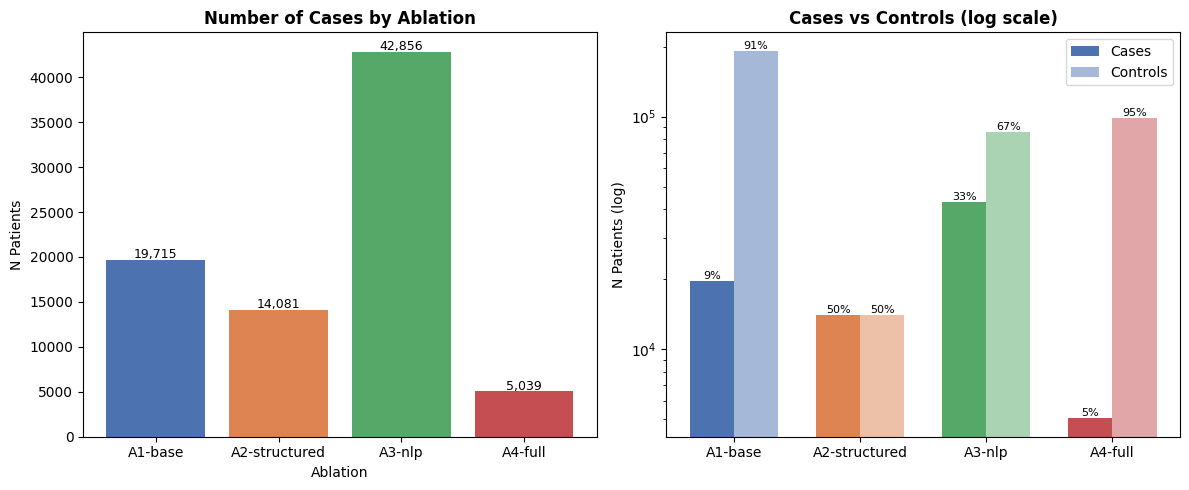

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart: case counts
ax = axes[0]
ax.bar(ABLATIONS, [data[k]["n_cases"] for k in ABLATIONS], color=COLORS)
ax.set_title("Number of Cases by Ablation", fontweight="bold")
ax.set_ylabel("N Patients")
ax.set_xlabel("Ablation")
for i, k in enumerate(ABLATIONS):
    ax.text(
        i, data[k]["n_cases"] + 200, f"{data[k]['n_cases']:,}", ha="center", fontsize=9
    )

# Grouped bar: cases vs controls (log scale for readability)
ax = axes[1]
x = np.arange(len(ABLATIONS))
w = 0.35
bars_cases = ax.bar(
    x - w / 2, [data[k]["n_cases"] for k in ABLATIONS], w, label="Cases", color=COLORS
)
bars_controls = ax.bar(
    x + w / 2,
    [data[k]["n_controls"] for k in ABLATIONS],
    w,
    label="Controls",
    color=COLORS,
    alpha=0.5,
)
ax.set_yscale("log")
ax.set_title("Cases vs Controls (log scale)", fontweight="bold")
ax.set_ylabel("N Patients (log)")
ax.set_xticks(x)
ax.set_xticklabels(ABLATIONS)
ax.legend()

# Percent labels above each bar
for i, k in enumerate(ABLATIONS):
    total = data[k]["n_cases"] + data[k]["n_controls"]
    case_pct = 100 * data[k]["n_cases"] / total
    ctrl_pct = 100 * data[k]["n_controls"] / total
    ax.text(
        x[i] - w / 2,
        data[k]["n_cases"],
        f"{case_pct:.0f}%",
        ha="center",
        va="bottom",
        fontsize=8,
    )
    ax.text(
        x[i] + w / 2,
        data[k]["n_controls"],
        f"{ctrl_pct:.0f}%",
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

## 2. Patient Overlap Between Ablations (Cases)

In [57]:
# Pairwise overlap matrix for cases
overlap_data = []
for a in ABLATIONS:
    row = []
    for b in ABLATIONS:
        overlap = len(case_sets[a] & case_sets[b])
        row.append(overlap)
    overlap_data.append(row)

overlap_df = pd.DataFrame(overlap_data, index=ABLATIONS, columns=ABLATIONS)
print("Pairwise case overlap (number of shared patients):")
print(overlap_df.to_string())
print()

# As Jaccard similarity
jaccard_data = []
for a in ABLATIONS:
    row = []
    for b in ABLATIONS:
        inter = len(case_sets[a] & case_sets[b])
        union = len(case_sets[a] | case_sets[b])
        row.append(inter / union if union else 0)
    jaccard_data.append(row)

jaccard_df = pd.DataFrame(jaccard_data, index=ABLATIONS, columns=ABLATIONS)
print("Pairwise Jaccard similarity (cases):")
print(jaccard_df.round(3).to_string())

Pairwise case overlap (number of shared patients):
               A1-base  A2-structured  A3-nlp  A4-full
A1-base          19715          14081   16608     4346
A2-structured    14081          14081   11742     3422
A3-nlp           16608          11742   42856     4830
A4-full           4346           3422    4830     5039

Pairwise Jaccard similarity (cases):
               A1-base  A2-structured  A3-nlp  A4-full
A1-base          1.000          0.714   0.361    0.213
A2-structured    0.714          1.000   0.260    0.218
A3-nlp           0.361          0.260   1.000    0.112
A4-full          0.213          0.218   0.112    1.000


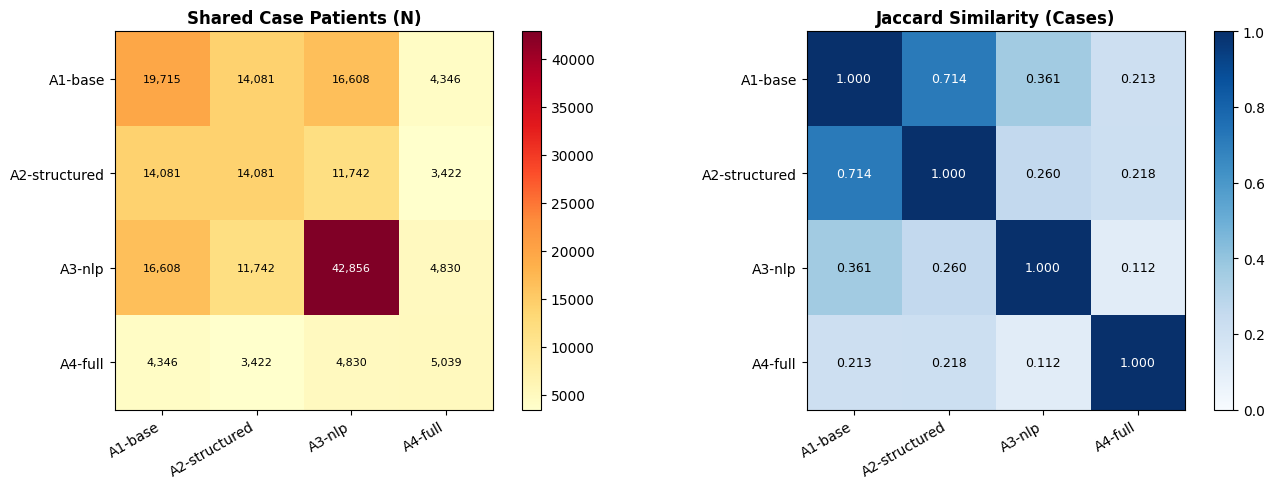

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap: pairwise overlap counts
ax = axes[0]
im = ax.imshow(overlap_df.values, cmap="YlOrRd")
ax.set_xticks(range(len(ABLATIONS)))
ax.set_yticks(range(len(ABLATIONS)))
ax.set_xticklabels(ABLATIONS, rotation=30, ha="right")
ax.set_yticklabels(ABLATIONS)
ax.set_title("Shared Case Patients (N)", fontweight="bold")
plt.colorbar(im, ax=ax)
for i in range(len(ABLATIONS)):
    for j in range(len(ABLATIONS)):
        ax.text(
            j,
            i,
            f"{overlap_df.values[i, j]:,}",
            ha="center",
            va="center",
            fontsize=8,
            color="black"
            if overlap_df.values[i, j] < overlap_df.values.max() * 0.7
            else "white",
        )

# Heatmap: Jaccard
ax = axes[1]
im2 = ax.imshow(jaccard_df.values, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(ABLATIONS)))
ax.set_yticks(range(len(ABLATIONS)))
ax.set_xticklabels(ABLATIONS, rotation=30, ha="right")
ax.set_yticklabels(ABLATIONS)
ax.set_title("Jaccard Similarity (Cases)", fontweight="bold")
plt.colorbar(im2, ax=ax)
for i in range(len(ABLATIONS)):
    for j in range(len(ABLATIONS)):
        ax.text(
            j,
            i,
            f"{jaccard_df.values[i, j]:.3f}",
            ha="center",
            va="center",
            fontsize=9,
            color="black" if jaccard_df.values[i, j] < 0.6 else "white",
        )

plt.tight_layout()
plt.show()

In [59]:
# Patients unique to each ablation
print("Cases UNIQUE to each ablation (not in any other):")
for k in ABLATIONS:
    others = set().union(*[case_sets[other] for other in ABLATIONS if other != k])
    unique = case_sets[k] - others
    print(
        f"  {k}: {len(unique):,} unique / {len(case_sets[k]):,} total ({100 * len(unique) / len(case_sets[k]):.1f}%)"
    )

print()
print("Cases in ALL four ablations:")
all_four = (
    case_sets["A1-base"]
    & case_sets["A2-structured"]
    & case_sets["A3-nlp"]
    & case_sets["A4-full"]
)
print(f"  {len(all_four):,} patients")

print()
print("Cases in A1 but NOT in A2 (lost by stricter >=2 admissions + age cutoff):")
print(f"  {len(case_sets['A1-base'] - case_sets['A2-structured']):,}")

print()
print("Cases in A3 but NOT in A1 (NLP expansion recovered):")
print(f"  {len(case_sets['A3-nlp'] - case_sets['A1-base']):,}")

Cases UNIQUE to each ablation (not in any other):
  A1-base: 729 unique / 19,715 total (3.7%)
  A2-structured: 0 unique / 14,081 total (0.0%)
  A3-nlp: 25,573 unique / 42,856 total (59.7%)
  A4-full: 18 unique / 5,039 total (0.4%)

Cases in ALL four ablations:
  3,270 patients

Cases in A1 but NOT in A2 (lost by stricter >=2 admissions + age cutoff):
  5,634

Cases in A3 but NOT in A1 (NLP expansion recovered):
  26,248


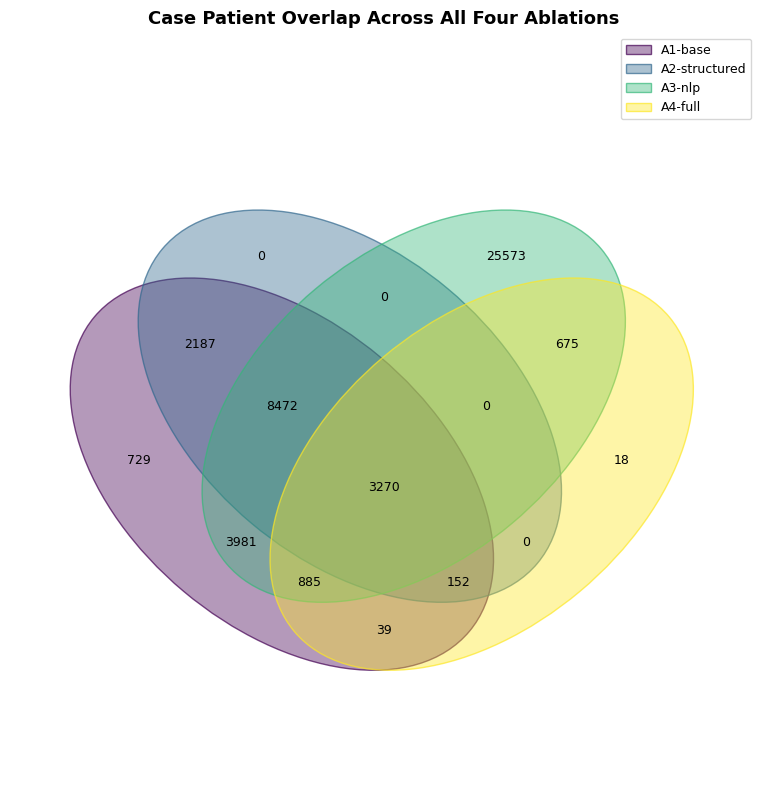

In [60]:
# 4-way Venn diagram: case overlap across all four ablations
fig, ax = plt.subplots(figsize=(10, 8))

venn(
    {k: case_sets[k] for k in ABLATIONS},
    ax=ax,
    fontsize=9,
    legend_loc="upper right",
)
ax.set_title(
    "Case Patient Overlap Across All Four Ablations", fontweight="bold", fontsize=13
)

plt.tight_layout()
plt.show()

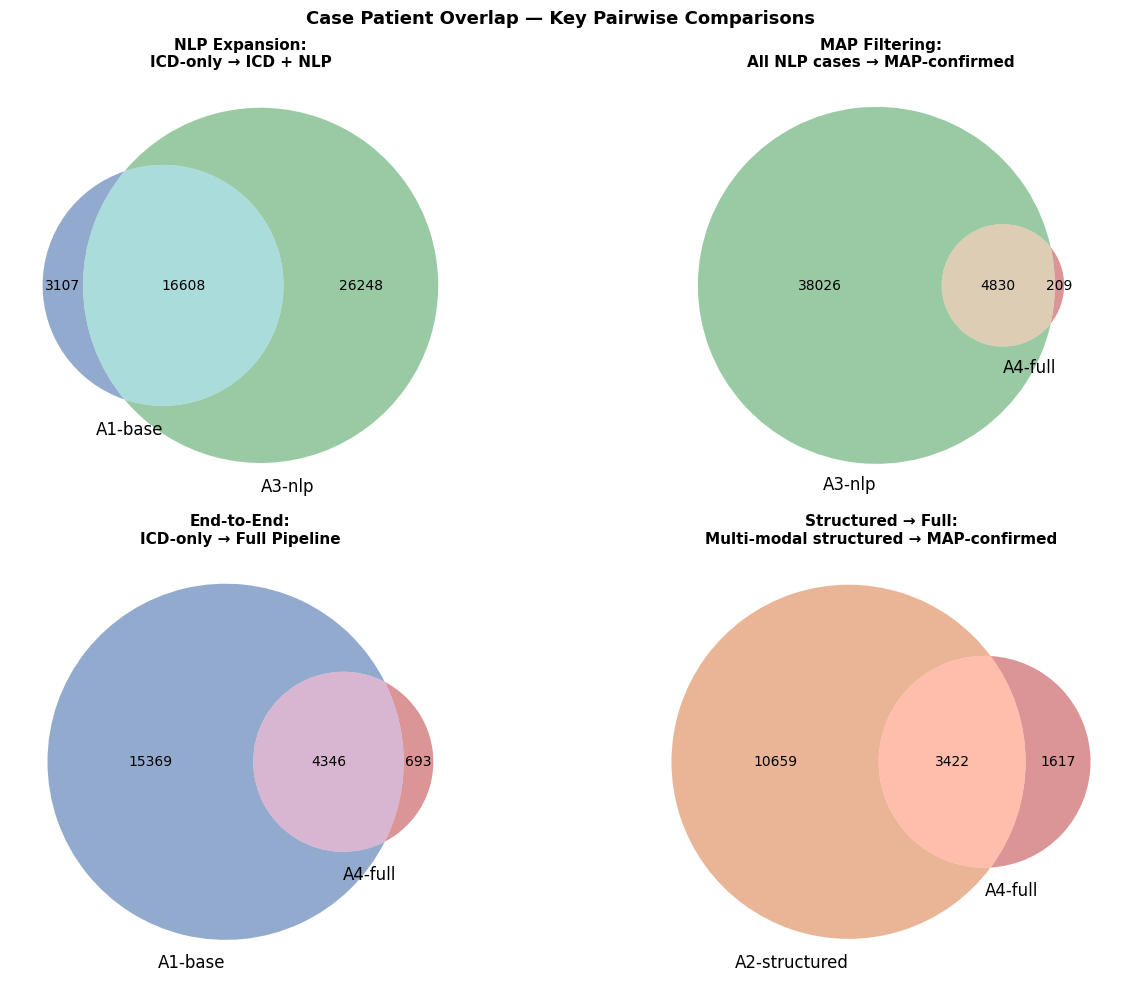

In [61]:
# Focused 2-way Venns: four key pairwise comparisons
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

pairs = [
    ("A1-base", "A3-nlp", "NLP Expansion:\nICD-only → ICD + NLP"),
    ("A3-nlp", "A4-full", "MAP Filtering:\nAll NLP cases → MAP-confirmed"),
    ("A1-base", "A4-full", "End-to-End:\nICD-only → Full Pipeline"),
    (
        "A2-structured",
        "A4-full",
        "Structured → Full:\nMulti-modal structured → MAP-confirmed",
    ),
]

for ax, (a, b, title) in zip(axes, pairs):
    venn2(
        [case_sets[a], case_sets[b]],
        set_labels=(a, b),
        ax=ax,
        set_colors=(COLOR_MAP[a], COLOR_MAP[b]),
        alpha=0.6,
    )
    ax.set_title(title, fontweight="bold", fontsize=11)

plt.suptitle(
    "Case Patient Overlap — Key Pairwise Comparisons", fontweight="bold", fontsize=13
)
plt.tight_layout()
plt.show()

## 3. CONSORT Flow Comparison

In [62]:
print("CONSORT flow by ablation:")
for k in ABLATIONS:
    print(f"\n--- {k} ---")
    for step in data[k]["consort_flow"]:
        pct = ""
        if step["n"] and data[k]["consort_flow"][0]["n"]:
            pct = (
                f"  ({100 * step['n'] / data[k]['consort_flow'][0]['n']:.1f}% of total)"
            )
        print(f"  {step['stage']:55s} {step['n']:>8,}{pct}")

CONSORT flow by ablation:

--- A1-base ---
  total patients in MIMIC-IV                               364,627  (100.0% of total)
  patients with >=1 admission                              223,452  (61.3% of total)
  adult patients (age >=18)                                223,452  (61.3% of total)
  anchor ICD candidates (>=1 HF code, adult)                31,369  (8.6% of total)
  final cases (>=2 HF encounters)                           19,715  (5.4% of total)
  final controls (no HF codes, adult)                      192,083  (52.7% of total)

--- A2-structured ---
  total patients in MIMIC-IV                               364,627  (100.0% of total)
  anchor ICD candidates (≥1 HF code)                        31,369  (8.6% of total)
  after ≥2 admissions threshold                             14,081  (3.9% of total)
  after age ≥18 exclusion                                   14,081  (3.9% of total)
  final cases                                               14,081  (3.9% of total)
  f

## 4. Comorbidity Prevalence Comparison

In [63]:
# Collect all comorbidity keys across all ablations
all_comorbidities = sorted(
    set().union(*[data[k]["comorbidity_prevalence_cases"].keys() for k in ABLATIONS])
)

comorbidity_df = pd.DataFrame(
    {k: data[k]["comorbidity_prevalence_cases"] for k in ABLATIONS},
    index=all_comorbidities,
).fillna(float("nan"))

print("Comorbidity prevalence in cases (proportion):")
print(comorbidity_df.round(3).to_string())

Comorbidity prevalence in cases (proportion):
                           A1-base  A2-structured  A3-nlp  A4-full
anemia                       0.665          0.246   0.300      NaN
atrial_fibrillation          0.568          0.600   0.433    0.651
cardiomyopathy                 NaN          0.264   0.111    0.292
chronic_pulmonary_disease    0.380            NaN     NaN      NaN
ckd                          0.519          0.780   0.507    0.635
copd                           NaN          0.321   0.193      NaN
coronary_artery_disease      0.630          0.735   0.535    0.717
diabetes                     0.480          0.548   0.344    0.501
hypertension                 0.896          0.939   0.822    0.897
obesity                      0.244          0.330   0.202      NaN
pulmonary_hypertension         NaN            NaN   0.176    0.015
sleep_apnea                    NaN          0.255   0.024      NaN
valvular_disease               NaN            NaN   0.090    0.265


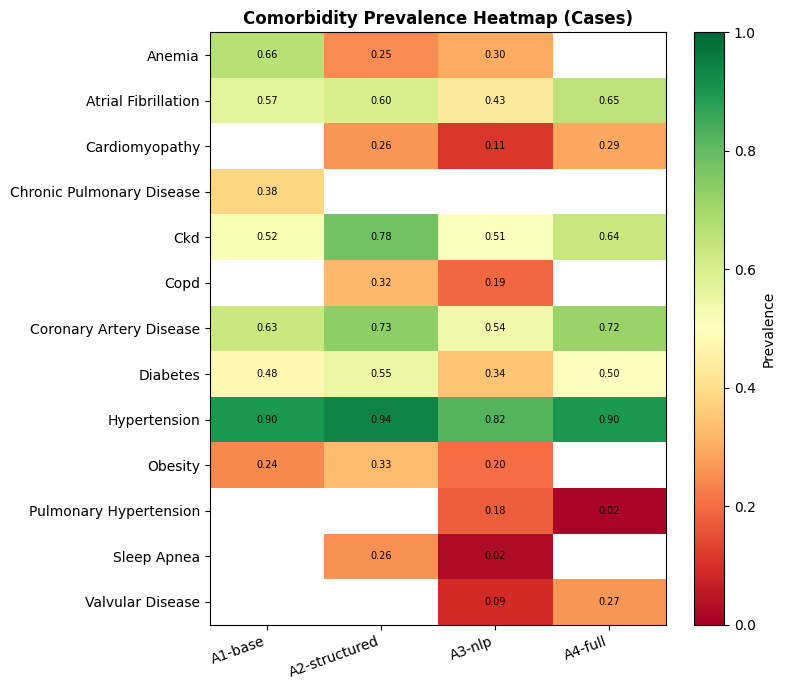

In [64]:
# Heatmap of all comorbidities
fig, ax = plt.subplots(figsize=(8, 7))
vals = comorbidity_df.values.astype(float)
im = ax.imshow(vals, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(ABLATIONS)))
ax.set_yticks(range(len(all_comorbidities)))
ax.set_xticklabels(ABLATIONS, rotation=20, ha="right")
ax.set_yticklabels([c.replace("_", " ").title() for c in all_comorbidities])
ax.set_title("Comorbidity Prevalence Heatmap (Cases)", fontweight="bold")
plt.colorbar(im, ax=ax, label="Prevalence")
for i in range(len(all_comorbidities)):
    for j in range(len(ABLATIONS)):
        v = vals[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7)
plt.tight_layout()
plt.show()

## 5. Top Driving Codes

In [65]:
# Display top 10 driving codes per ablation
for k in ABLATIONS:
    print(f"\n=== {k} — Top 10 Driving Codes ===")
    codes = data[k]["top_driving_codes"][:10]
    for entry in codes:
        code = entry.get("code", "")
        label = entry.get("label", entry.get("code", ""))
        # pick the most informative numeric field
        metric = (
            f"prevalence={entry['prevalence_in_cases']:.3f}"
            if "prevalence_in_cases" in entry
            else f"enrichment={entry['enrichment']:.1f}"
            if "enrichment" in entry
            else f"prevalence={entry['prevalence']:.3f}"
            if "prevalence" in entry
            else f"weight={entry['weight']:.4f}"
            if "weight" in entry
            else ""
        )
        print(f"  {code:30s}  {label:45s}  {metric}")


=== A1-base — Top 10 Driving Codes ===
  4019                            4019                                           prevalence=0.485
  2724                            2724                                           prevalence=0.454
  42731                           42731                                          prevalence=0.371
  41401                           41401                                          prevalence=0.370
  E785                            E785                                           prevalence=0.369
  5849                            5849                                           prevalence=0.346
  I2510                           I2510                                          prevalence=0.296
  N179                            N179                                           prevalence=0.292
  25000                           25000                                          prevalence=0.287
  40390                           40390                                       

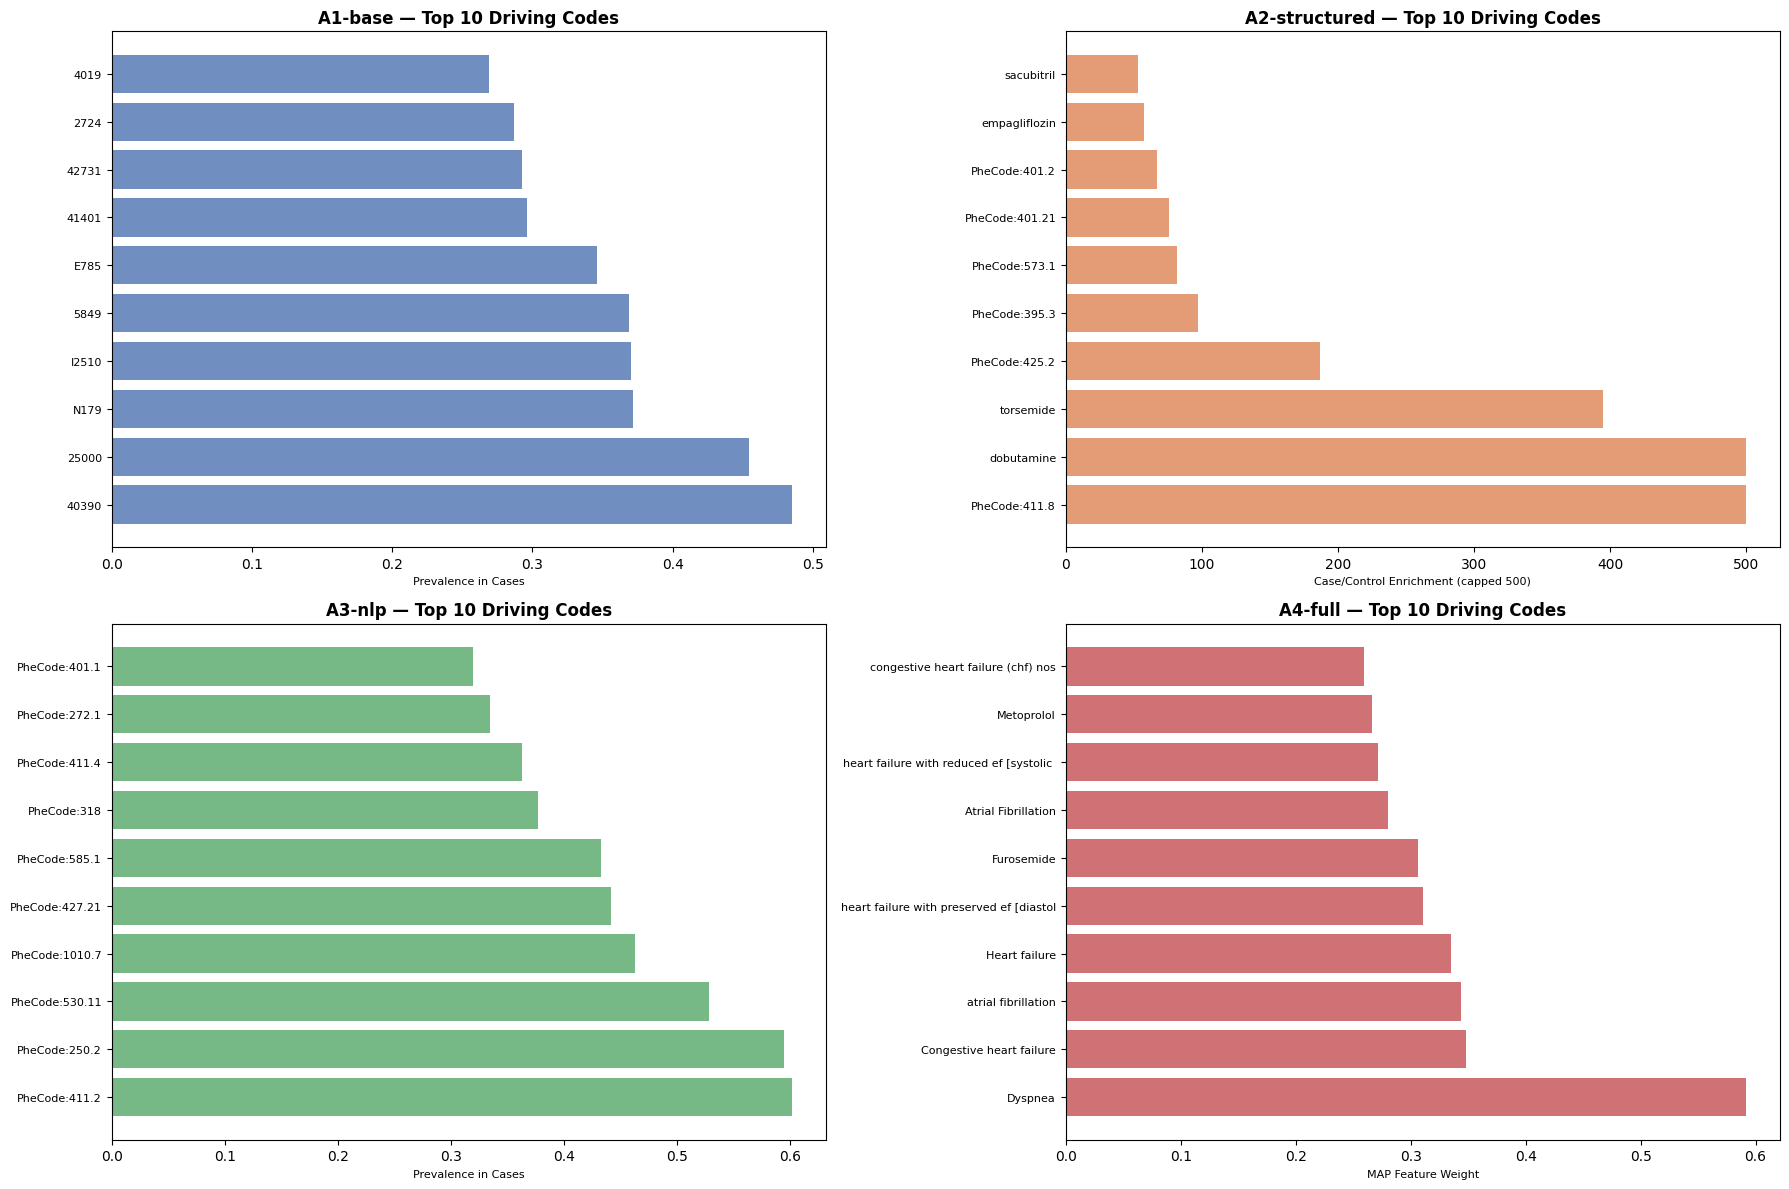

In [66]:
# Horizontal bar chart for each ablation's top-10 codes
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, (k, color) in zip(axes, zip(ABLATIONS, COLORS)):
    codes = data[k]["top_driving_codes"][:10]
    labels = [entry.get("label", entry.get("code", ""))[:40] for entry in codes]

    # pick numeric metric (higher = more informative)
    def get_metric(e):
        if "weight" in e:
            return e["weight"]
        if "enrichment" in e:
            return min(e["enrichment"], 500)  # cap for readability
        if "prevalence_in_cases" in e:
            return e["prevalence_in_cases"]
        if "prevalence" in e:
            return e["prevalence"]
        return 0

    metric_label = {
        "A1-base": "Prevalence in Cases",
        "A2-structured": "Case/Control Enrichment (capped 500)",
        "A3-nlp": "Prevalence in Cases",
        "A4-full": "MAP Feature Weight",
    }[k]
    vals = [get_metric(e) for e in codes]
    y = range(len(labels))
    ax.barh(
        list(reversed(range(len(labels)))), list(reversed(vals)), color=color, alpha=0.8
    )
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(list(reversed(labels)), fontsize=8)
    ax.set_xlabel(metric_label, fontsize=8)
    ax.set_title(f"{k} — Top 10 Driving Codes", fontweight="bold")

plt.tight_layout()
plt.show()

## 6. A4-Specific: MAP vs ICD Agreement

A4-full MAP vs ICD breakdown:
  ICD anchor candidates:               31,414
  Final MAP cases:                     5,039
  ICD-coded but MAP-rejected:          26,375
  MAP-found (ICD-negative):            0
  Acceptance rate (MAP/ICD anchors):   16.0%


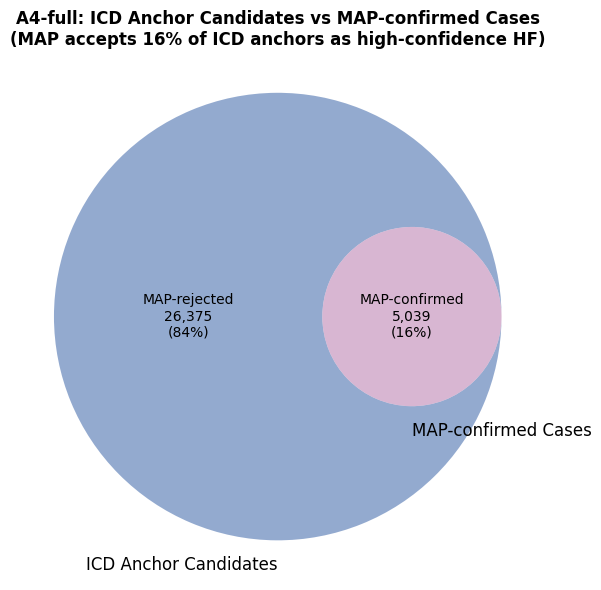

In [67]:
d4 = data["A4-full"]
icd_only = d4.get("icd_only_count", 0)
map_only = d4.get("map_only_count", 0)
map_cases = d4["n_cases"]

# ICD anchor candidates from consort flow
icd_anchor_total = next(
    s["n"] for s in d4["consort_flow"] if "anchor" in s["stage"].lower()
)

print("A4-full MAP vs ICD breakdown:")
print(f"  ICD anchor candidates:               {icd_anchor_total:,}")
print(f"  Final MAP cases:                     {map_cases:,}")
print(f"  ICD-coded but MAP-rejected:          {icd_only:,}")
print(f"  MAP-found (ICD-negative):            {map_only:,}")
print(
    f"  Acceptance rate (MAP/ICD anchors):   {100 * map_cases / icd_anchor_total:.1f}%"
)

# Venn: ICD anchor candidates vs MAP-confirmed cases
# MAP cases (5,039) are a complete subset of ICD anchors (31,414) since map_only=0

fig, ax = plt.subplots(figsize=(7, 6))
v = venn2(
    subsets=(icd_anchor_total - map_cases, 0, map_cases),  # (ICD-only, MAP-only, both)
    set_labels=("ICD Anchor Candidates", "MAP-confirmed Cases"),
    set_colors=("#4C72B0", "#C44E52"),
    alpha=0.6,
    ax=ax,
)

# Annotate the regions clearly
if v.get_label_by_id("10"):
    v.get_label_by_id("10").set_text(
        f"MAP-rejected\n{icd_only:,}\n({100 * icd_only / icd_anchor_total:.0f}%)"
    )
if v.get_label_by_id("11"):
    v.get_label_by_id("11").set_text(
        f"MAP-confirmed\n{map_cases:,}\n({100 * map_cases / icd_anchor_total:.0f}%)"
    )
if v.get_label_by_id("01"):
    v.get_label_by_id("01").set_text("")  # map_only = 0, hide empty region

ax.set_title(
    "A4-full: ICD Anchor Candidates vs MAP-confirmed Cases\n"
    "(MAP accepts 16% of ICD anchors as high-confidence HF)",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## 7. Summary Statistics Table

In [68]:
# Build a comprehensive summary
rows = []
for k in ABLATIONS:
    d = data[k]
    others = [o for o in ABLATIONS if o != k]
    union_others = set().union(*[case_sets[o] for o in others])
    unique = len(case_sets[k] - union_others)
    rows.append(
        {
            "Ablation": k,
            "Features Used": ", ".join(d["feature_types_used"]).upper(),
            "N Cases": f"{d['n_cases']:,}",
            "N Controls": f"{d['n_controls']:,}",
            "Case:Control": f"1:{d['n_controls'] / d['n_cases']:.1f}",
            "Unique Cases (%)": f"{unique:,} ({100 * unique / d['n_cases']:.0f}%)",
            "In All 4 Ablations": len(case_sets[k] & all_four),
        }
    )

final_table = pd.DataFrame(rows).set_index("Ablation")
print(final_table.to_string())

                        Features Used N Cases N Controls Case:Control Unique Cases (%)  In All 4 Ablations
Ablation                                                                                                  
A1-base                           ICD  19,715    192,083        1:9.7         729 (4%)                3270
A2-structured       ICD, RX, LAB, CPT  14,081     14,081        1:1.0           0 (0%)                3270
A3-nlp         CPT, ICD, LAB, NLP, RX  42,856     85,712        1:2.0     25,573 (60%)                3270
A4-full        ICD, RX, LAB, CPT, NLP   5,039     98,550       1:19.6          18 (0%)                3270


## 8. Slide-Ready Ablation Figure

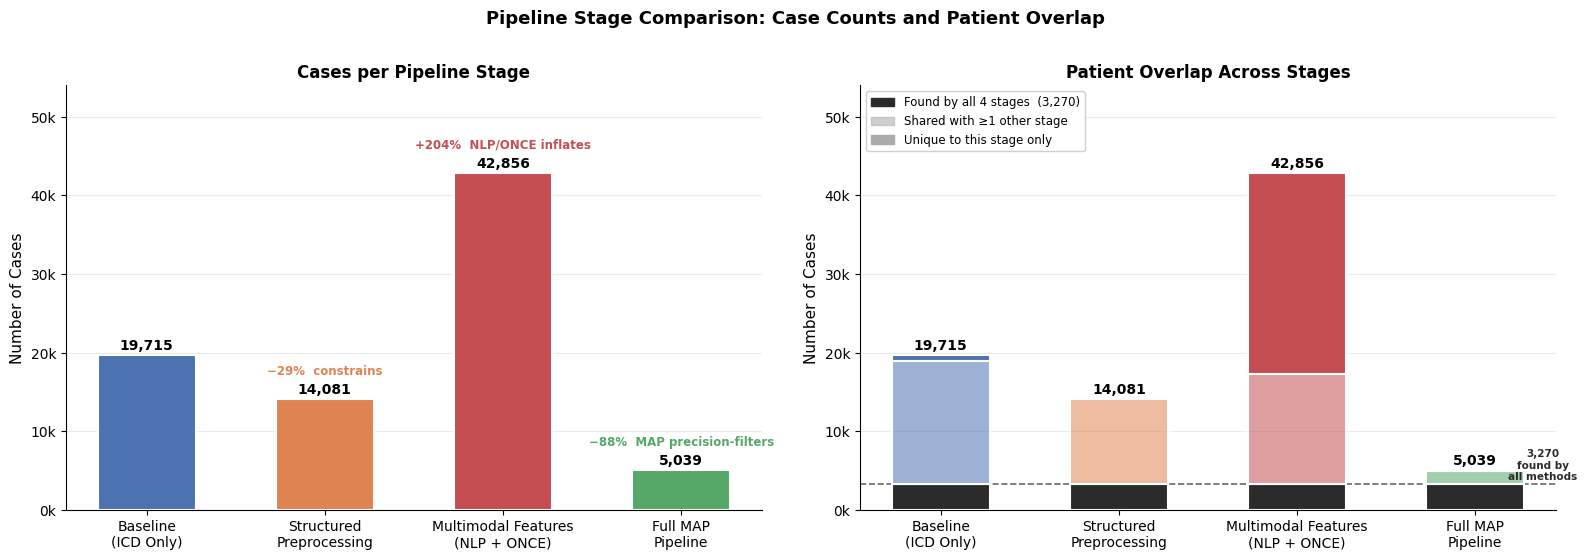

/var/folders/1f/mrpsxvfj2h57srgz2kqfw97m0000gn/T/ipykernel_81365/2987814401.py:238: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(


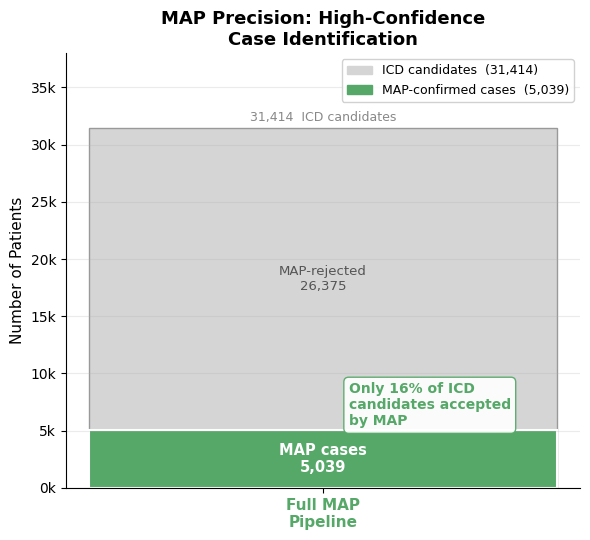

In [89]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np

# ─── Consistent labels and colors ───────────────────────────────────────────
LABELS = [
    "Baseline\n(ICD Only)",
    "Structured\nPreprocessing",
    "Multimodal Features\n(NLP + ONCE)",
    "Full MAP\nPipeline",
]
C = ["#4C72B0", "#DD8452", "#C44E52", "#55A868"]  # blue, orange, red, green

n_cases = [19715, 14081, 42856, 5039]

CORE = 3270
unique_n = [729, 0, 25573, 18]
shared_n = [n - CORE - u for n, u in zip(n_cases, unique_n)]

BAR_W = 0.55
YLIM = 54000


def style_ax(ax):
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x / 1000)}k"))
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, zorder=0)
    ax.set_ylim(0, YLIM)


def draw_left(ax):
    bars = ax.bar(
        range(4),
        n_cases,
        color=C,
        width=BAR_W,
        edgecolor="white",
        linewidth=1.5,
        zorder=2,
    )
    ax.set_xticks(range(4))
    ax.set_xticklabels(LABELS, fontsize=10)
    ax.set_ylabel("Number of Cases", fontsize=11)
    ax.set_title("Cases per Pipeline Stage", fontweight="bold", fontsize=12)
    style_ax(ax)
    for bar, count in zip(bars, n_cases):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            count + 350,
            f"{count:,}",
            ha="center",
            va="bottom",
            fontweight="bold",
            fontsize=10,
        )
    for j, pct, desc, col in [
        (1, "−29%", "constrains", C[1]),
        (2, "+204%", "NLP/ONCE inflates", C[2]),
        (3, "−88%", "MAP precision-filters", C[3]),
    ]:
        ax.text(
            j,
            n_cases[j] + 2800,
            f"{pct}  {desc}",
            ha="center",
            va="bottom",
            fontsize=8.5,
            color=col,
            fontweight="bold",
        )


def draw_right(ax):
    x = np.arange(4)
    ax.bar(
        x,
        [CORE] * 4,
        color="#2b2b2b",
        width=BAR_W,
        edgecolor="white",
        linewidth=1.5,
        zorder=2,
    )
    for i in range(4):
        r, g, b = mcolors.to_rgb(C[i])
        ax.bar(
            x[i],
            shared_n[i],
            bottom=CORE,
            color=(r, g, b, 0.55),
            width=BAR_W,
            edgecolor="white",
            linewidth=1.5,
            zorder=2,
        )
    for i in range(4):
        if unique_n[i] > 0:
            ax.bar(
                x[i],
                unique_n[i],
                bottom=CORE + shared_n[i],
                color=C[i],
                width=BAR_W,
                edgecolor="white",
                linewidth=1.5,
                zorder=2,
            )
    ax.set_xticks(x)
    ax.set_xticklabels(LABELS, fontsize=10)
    ax.set_ylabel("Number of Cases", fontsize=11)
    ax.set_title("Patient Overlap Across Stages", fontweight="bold", fontsize=12)
    style_ax(ax)
    for i, count in enumerate(n_cases):
        ax.text(
            i,
            count + 350,
            f"{count:,}",
            ha="center",
            va="bottom",
            fontweight="bold",
            fontsize=10,
        )
    ax.axhline(
        CORE, color="#2b2b2b", linestyle="--", linewidth=1.2, alpha=0.7, zorder=1
    )
    ax.text(
        3.38,
        CORE + 350,
        f"{CORE:,}\nfound by\nall methods",
        ha="center",
        va="bottom",
        fontsize=7.5,
        color="#2b2b2b",
        fontweight="bold",
    )
    ax.legend(
        handles=[
            mpatches.Patch(color="#2b2b2b", label=f"Found by all 4 stages  ({CORE:,})"),
            mpatches.Patch(
                color="#aaa", alpha=0.55, label="Shared with ≥1 other stage"
            ),
            mpatches.Patch(color="#aaa", label="Unique to this stage only"),
        ],
        fontsize=8.5,
        loc="upper left",
        framealpha=0.92,
    )


# ── Combined figure ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))
fig.suptitle(
    "Pipeline Stage Comparison: Case Counts and Patient Overlap",
    fontsize=13,
    fontweight="bold",
    y=1.01,
)
draw_left(ax1)
draw_right(ax2)
plt.tight_layout()
plt.show()


# ════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Full MAP Pipeline: precision filter on ICD candidates (unchanged)
# ════════════════════════════════════════════════════════════════════════════
icd_candidates = 31414
map_confirmed = 5039
map_rejected = icd_candidates - map_confirmed
pct_accepted = int(round(100 * map_confirmed / icd_candidates))

fig3, ax = plt.subplots(figsize=(6, 5.5))
ax.bar(
    [0], [icd_candidates], color="#D5D5D5", width=BAR_W, edgecolor="#999", linewidth=1
)
ax.bar(
    [0], [map_confirmed], color="#55A868", width=BAR_W, edgecolor="white", linewidth=1.5
)
ax.text(
    0,
    map_confirmed / 2,
    f"MAP cases\n{map_confirmed:,}",
    ha="center",
    va="center",
    color="white",
    fontsize=10.5,
    fontweight="bold",
)
ax.text(
    0,
    map_confirmed + map_rejected / 2,
    f"MAP-rejected\n{map_rejected:,}",
    ha="center",
    va="center",
    color="#555",
    fontsize=9.5,
)
ax.text(
    0,
    icd_candidates + 400,
    f"{icd_candidates:,}  ICD candidates",
    ha="center",
    va="bottom",
    fontsize=9,
    color="#888",
)
ax.text(
    0.55,
    0.19,
    f"Only {pct_accepted}% of ICD\ncandidates accepted\nby MAP",
    transform=ax.transAxes,
    ha="left",
    va="center",
    fontsize=10,
    color="#55A868",
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.35", facecolor="white", edgecolor="#55A868", alpha=0.92
    ),
)
ax.set_xticks([0])
ax.set_xticklabels(
    ["Full MAP\nPipeline"], fontsize=11, color="#55A868", fontweight="bold"
)
ax.set_ylabel("Number of Patients", fontsize=11)
ax.set_title(
    "MAP Precision: High-Confidence\nCase Identification",
    fontweight="bold",
    fontsize=13,
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x / 1000)}k"))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25, zorder=0)
ax.set_ylim(0, 38000)
ax.legend(
    handles=[
        mpatches.Patch(
            color="#D5D5D5",
            edgecolor="#999",
            label=f"ICD candidates  ({icd_candidates:,})",
        ),
        mpatches.Patch(
            color="#55A868", label=f"MAP-confirmed cases  ({map_confirmed:,})"
        ),
    ],
    fontsize=9,
    loc="upper right",
    framealpha=0.9,
)
plt.tight_layout()
plt.show()